In [18]:

from pathlib import Path
from typing import Sequence

import itertools
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

In [19]:

# path = "~/jobs/deploy/decode"
path = "../../"
path = Path(path).expanduser()
import sys

sys.path.insert(0, str(path))

In [20]:
import decode
import decode.neuralfitter.inference.functional as infer_func
print(decode.__file__)
log = decode.generic.logging.get_logger(__name__)

%config InlineBackend.figure_format='retina'

/home/shahao/projects/DECODE-Plex/notebook/debug/../../decode/__init__.py


In [ ]:

path_em = "../../results/Fig2a-MM_25ms_638i100_UVi20_focusloci30_1_MMStack_Default.ome_decode_plex_fit_model_Fig2a-dual_color-actin_microtubes.h5"
path_em = Path(path_em)

path_em.is_file()

True

In [22]:

em = decode.EmitterSet.load(path_em)
em = em[em.prob > 0.6]
em = em[em.xyz_sig_lat_nm < 20]
em.xyz_px

tensor([[  13.5632,   20.4811, -287.9719],
        [  14.4077,   43.1251,  -78.4351],
        [  14.9847,   53.6031, -197.3141],
        ...,
        [ 215.2799,   19.0230,  119.5613],
        [ 215.3587,   24.7841,  216.7264],
        [ 214.5198,   33.7716,   92.1845]])

In [23]:
offsets = em.xyz_px[:, :2].clone()
ix = torch.zeros_like(offsets, dtype=torch.long)

for i in range(2):
    offsets[:, i], ix[:, i] = decode.evaluation.predict_dist.px_pointer_dist(offsets[:, i], -0.5, 1., return_ix=True)

In [24]:

debias = decode.neuralfitter.de_bias.UniformizeOffsetCoordinateBased(10)
debias_by_z = decode.neuralfitter.de_bias.DebiasLateral(debias, 10)

# doffset = debias.forward(offsets, em.xyz_sig_px[:, :2])
doffset, ixx = debias_by_z.forward(offsets, em.xyz_sig_px[:, :2], em.xyz_px[:, 2])
_, ix_reverse = torch.sort(ixx, dim=0)

doffset = doffset[ix_reverse]

In [25]:

# new coordinates
em_debiased = em.clone()
em_debiased.xyz_px[:, :2] = ix + doffset
em_debiased.save(path_em.with_name(f"{path_em.stem}_debiased.h5"))

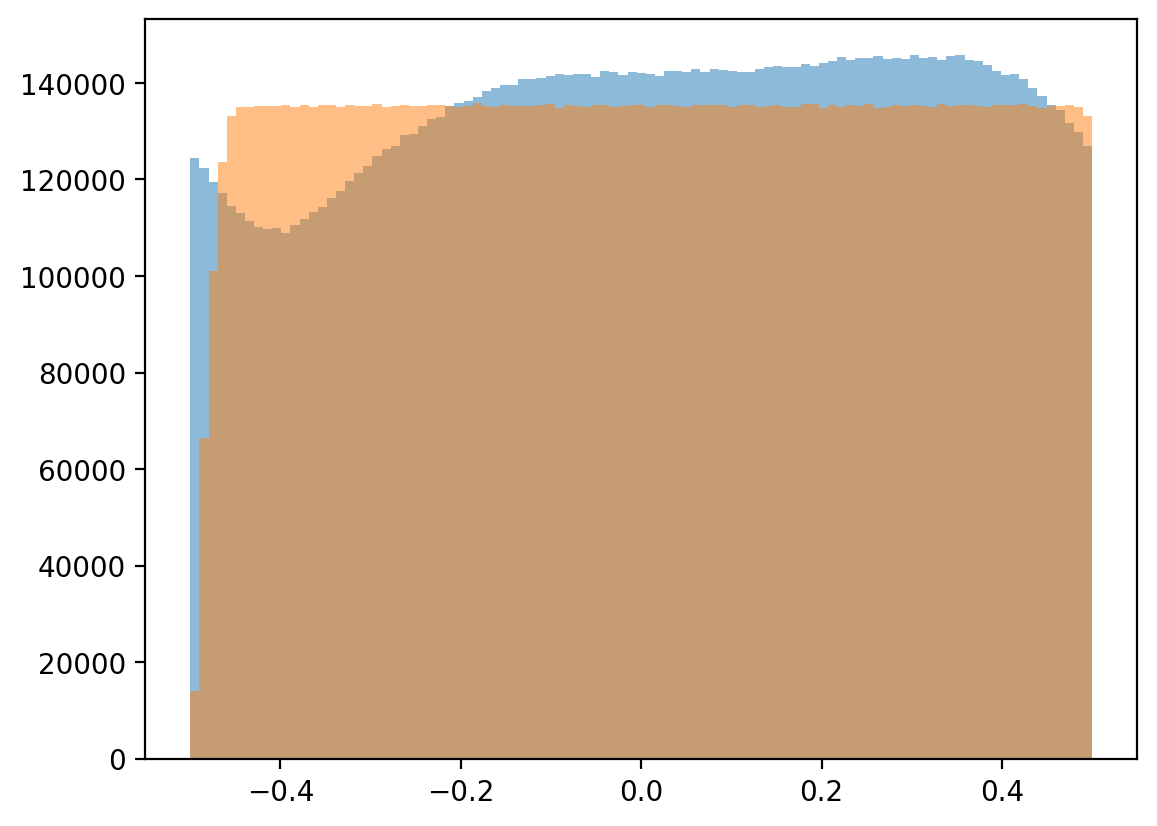

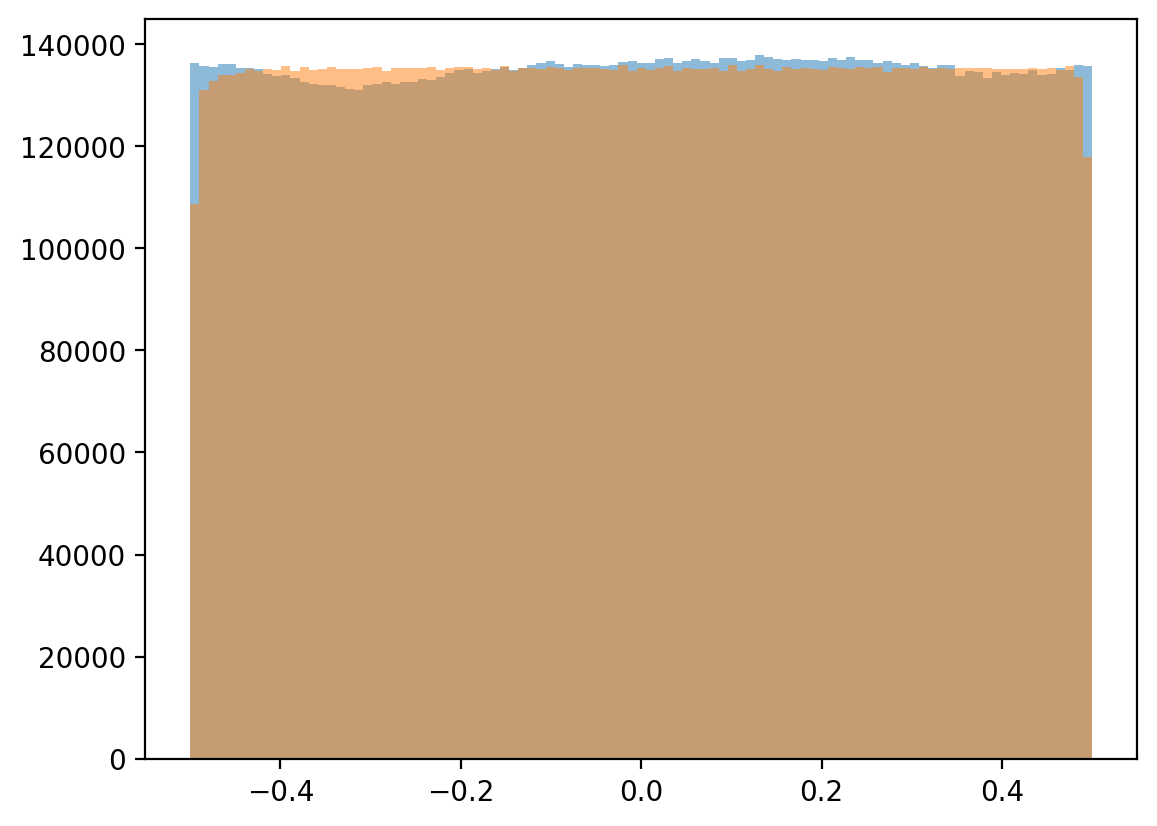

In [26]:

for i in range(2):
    _ = plt.hist(offsets[:, i].numpy(), bins=torch.linspace(-0.5, 0.5, 100).numpy(), alpha=0.5)
    _ = plt.hist(doffset[:, i].numpy(), bins=torch.linspace(-0.5, 0.5, 100).numpy(), alpha=0.5)
    plt.show()

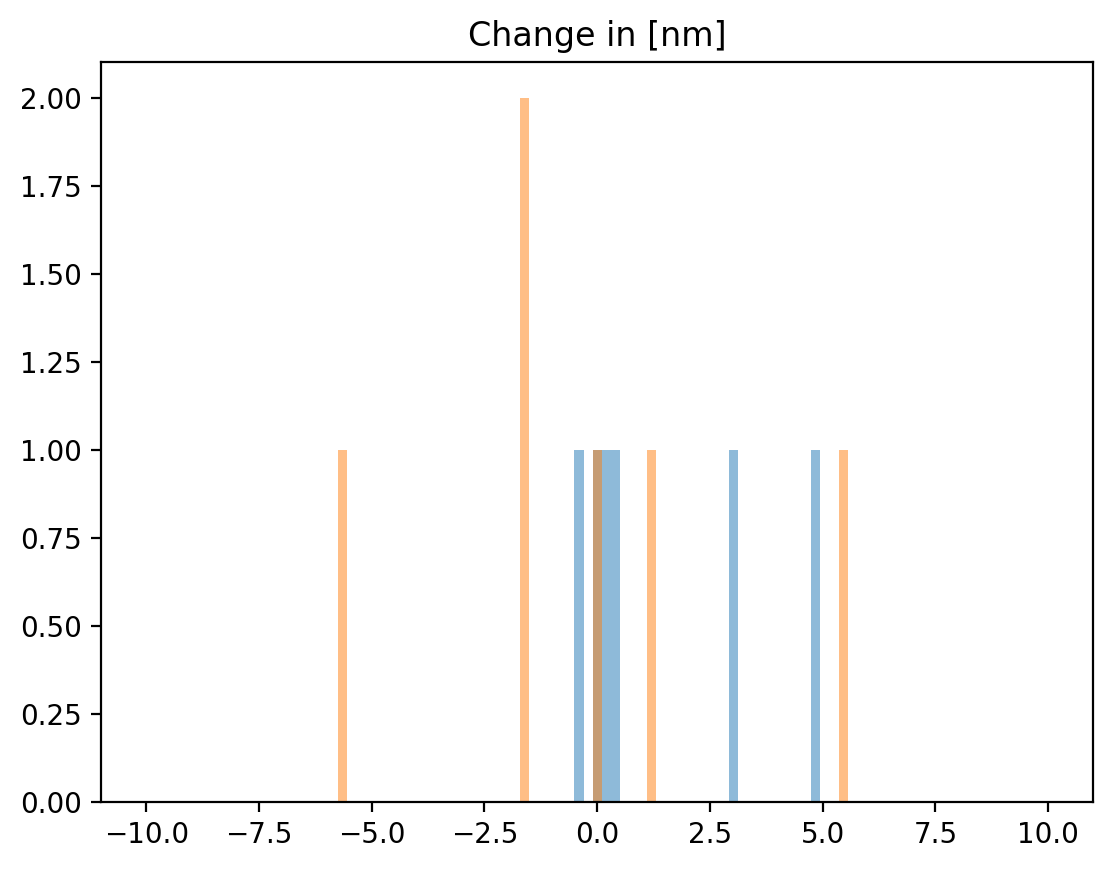

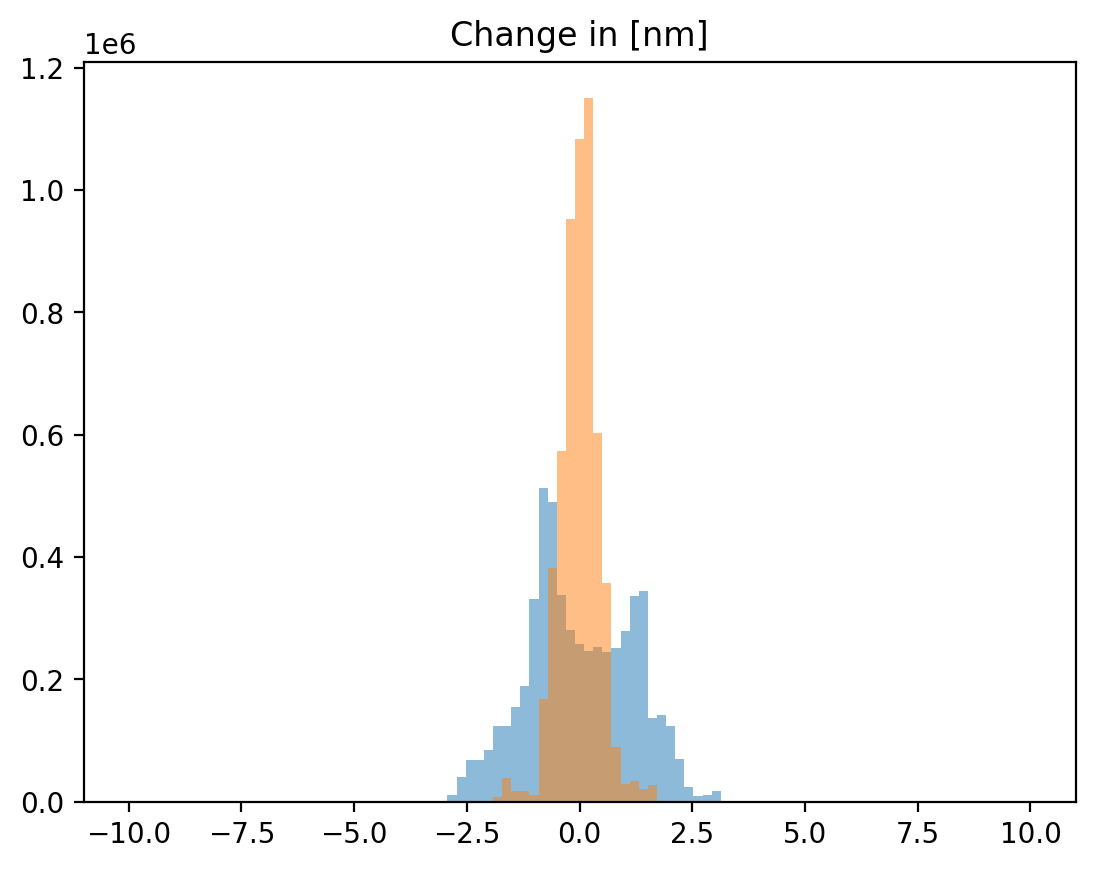

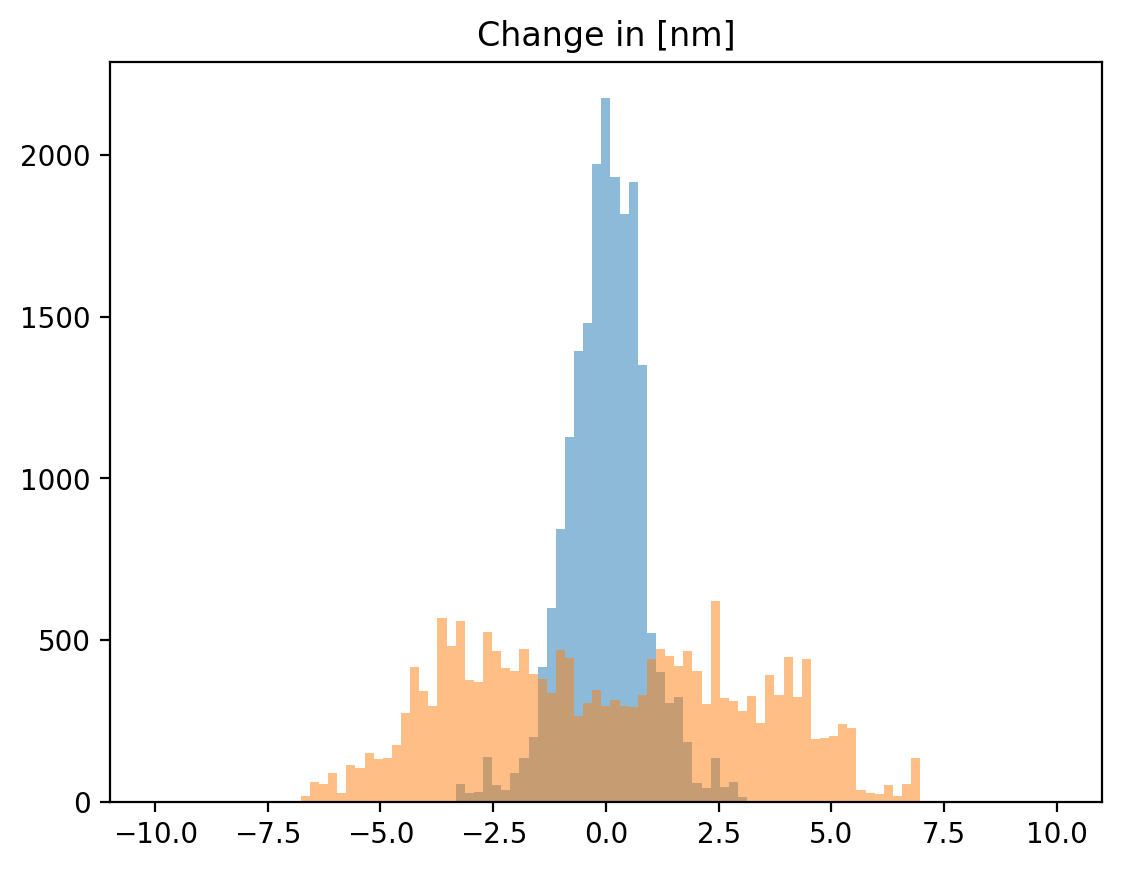

In [27]:
delta_nm = (doffset - offsets) * 100
range_z = [(-1000, -500), (-100, 100), (500, 1000)]

for rz in range_z:
    mask = (em.xyz_nm[:, 2] > rz[0]) & (em.xyz_nm[:, 2] < rz[1])
    delta_nm_z = delta_nm[mask]

    for i in range(2):
        _ = plt.hist(delta_nm_z[:, i].numpy(), bins=torch.linspace(-10, 10, 100).numpy(), alpha=0.5)

    plt.title("Change in [nm]")
    plt.show()

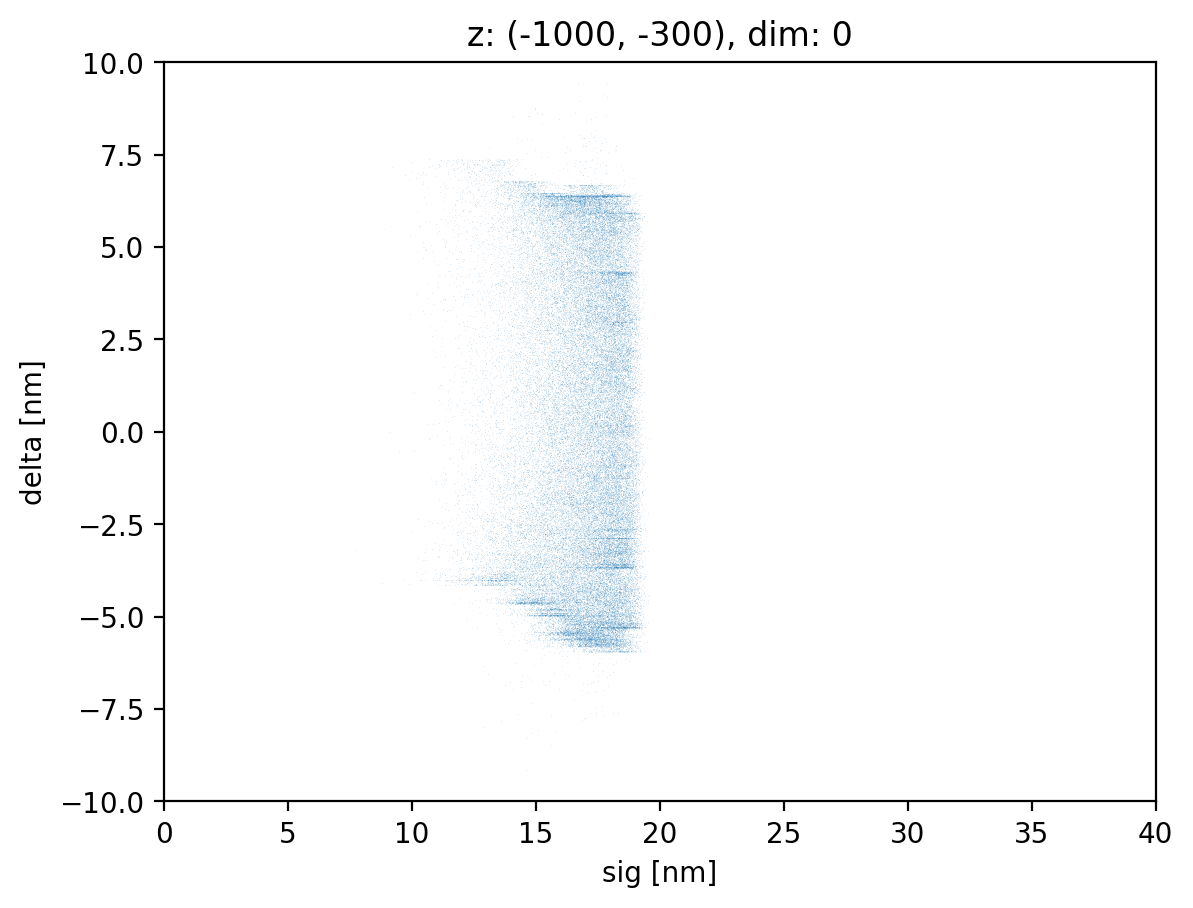

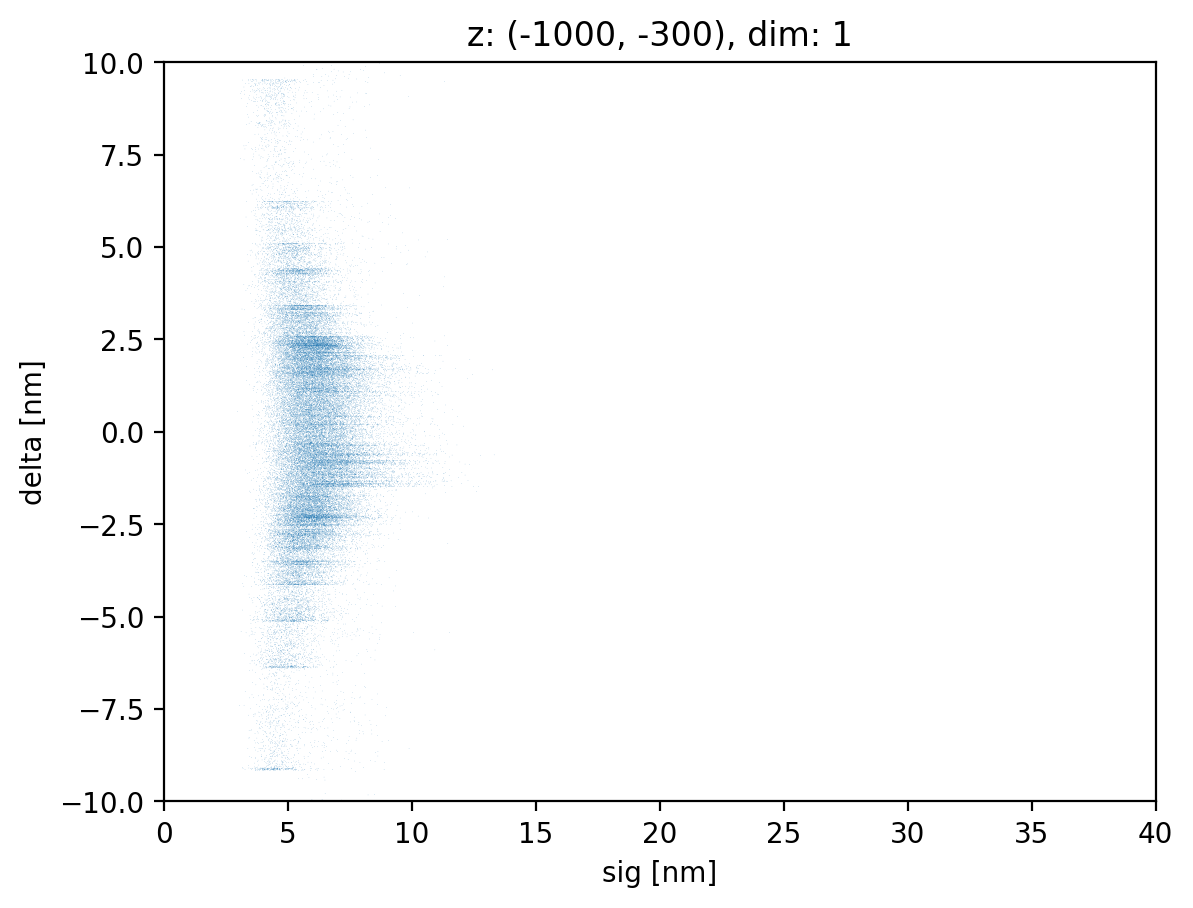

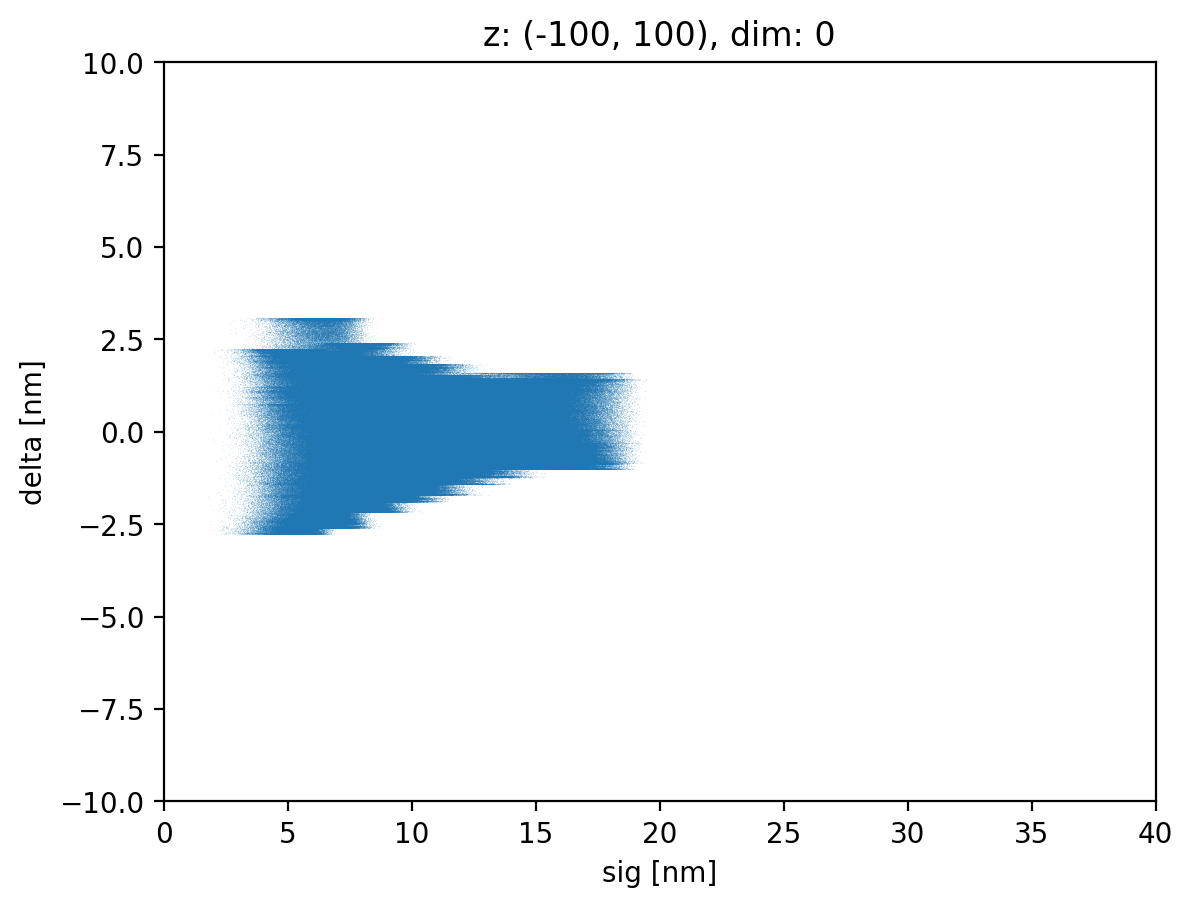

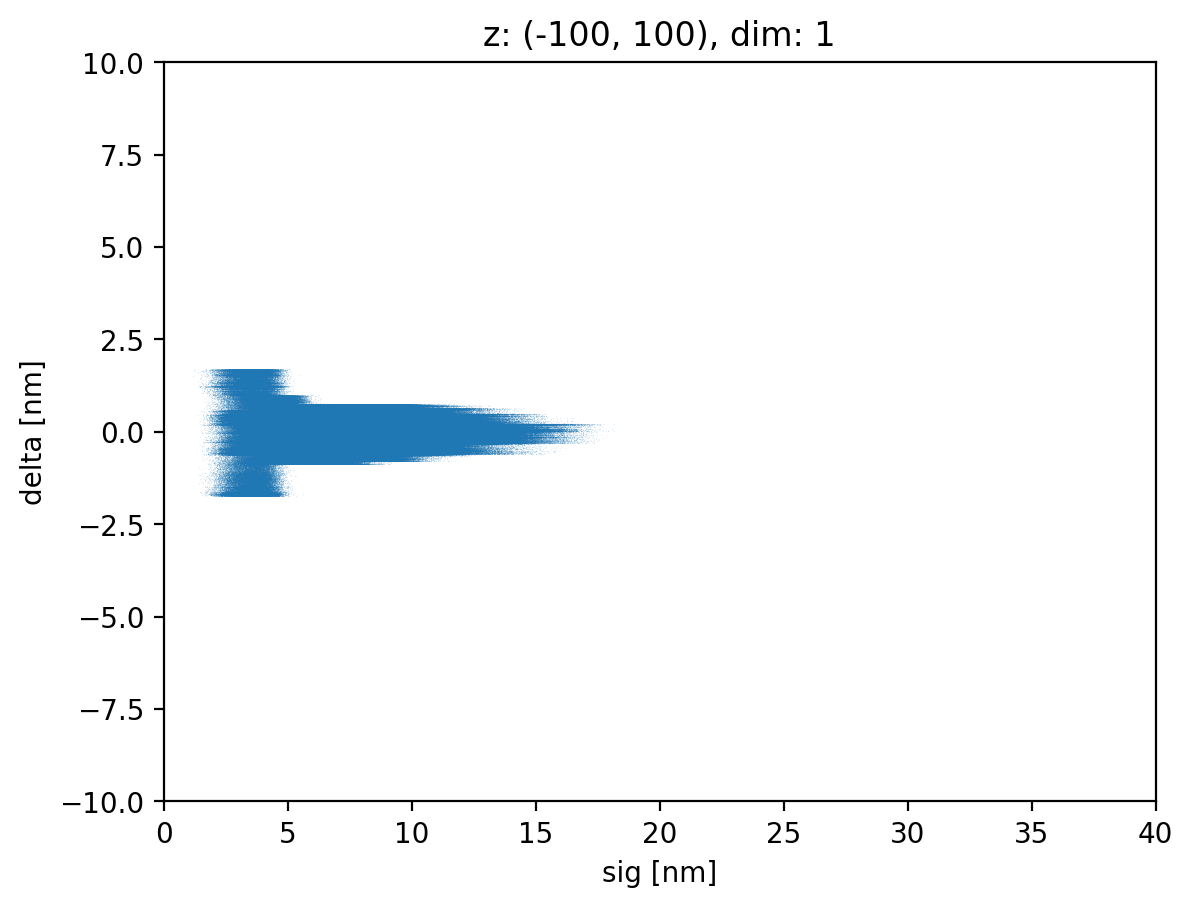

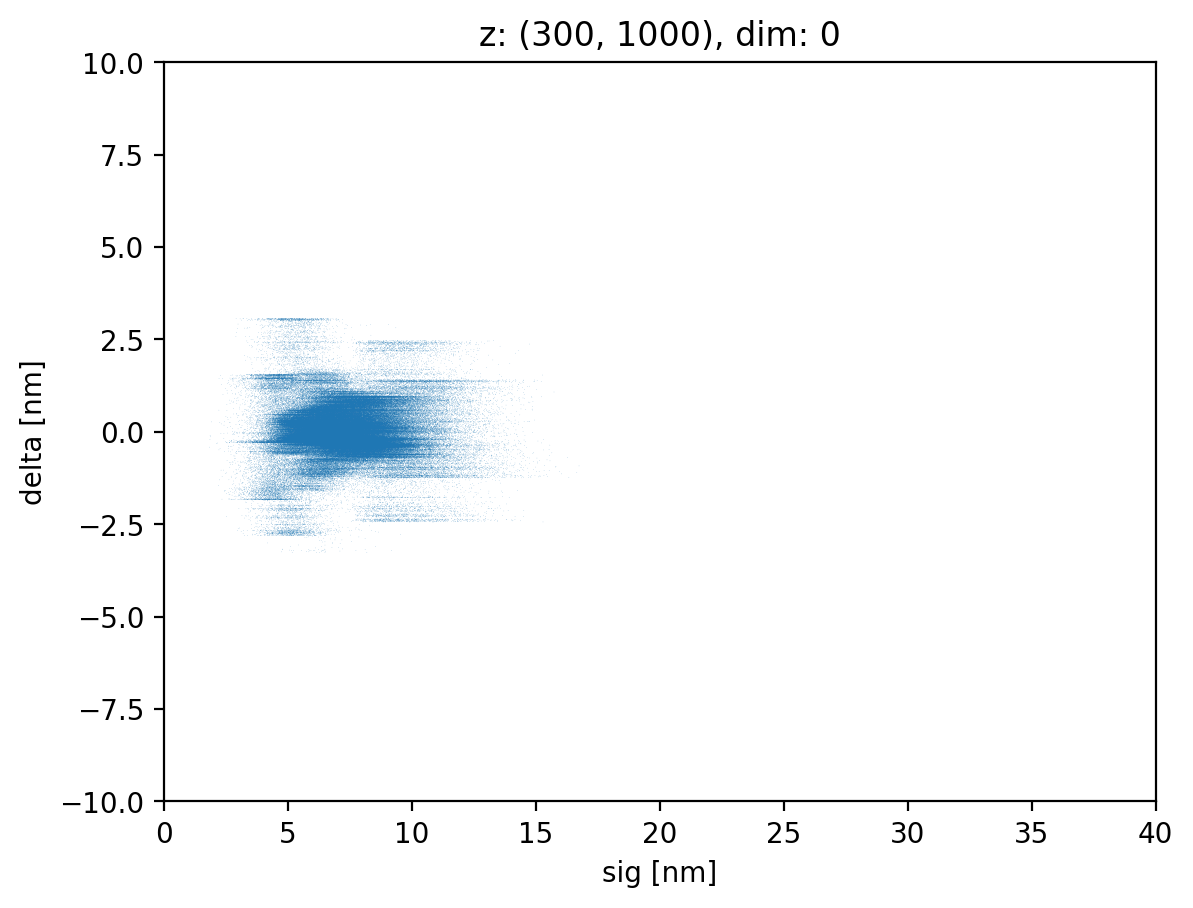

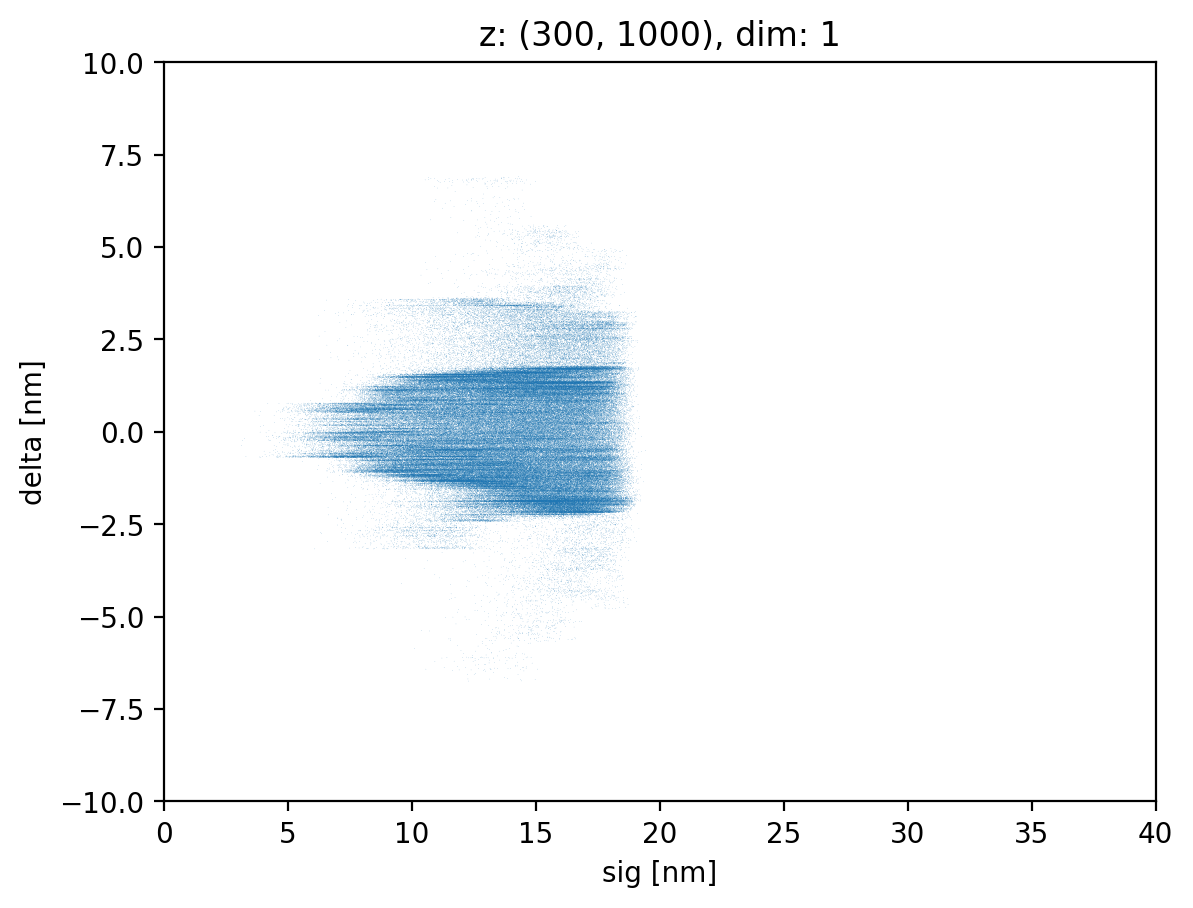

In [28]:

range_z = [(-1000, -300), (-100, 100), (300, 1000)]

for rz in range_z:
    mask = (em.xyz_nm[:, 2] > rz[0]) & (em.xyz_nm[:, 2] < rz[1])

    em_z = em[mask]
    delta_nm_z = delta_nm[mask]

    for i in range(2):
        plt.scatter(em_z.xyz_sig_nm[::2, i], delta_nm_z[::2, i], s=0.1, marker=".", edgecolors="none")
        plt.xlabel("sig [nm]")
        plt.ylabel("delta [nm]")

        plt.xlim(0, 40)
        plt.ylim(-10, 10)
        plt.title(f"z: {rz}, dim: {i}")
        # path_out = f"/Users/lucasmueller/Downloads/offset_{rz}_{i}.png"
        # plt.savefig(path_out)
        plt.show()

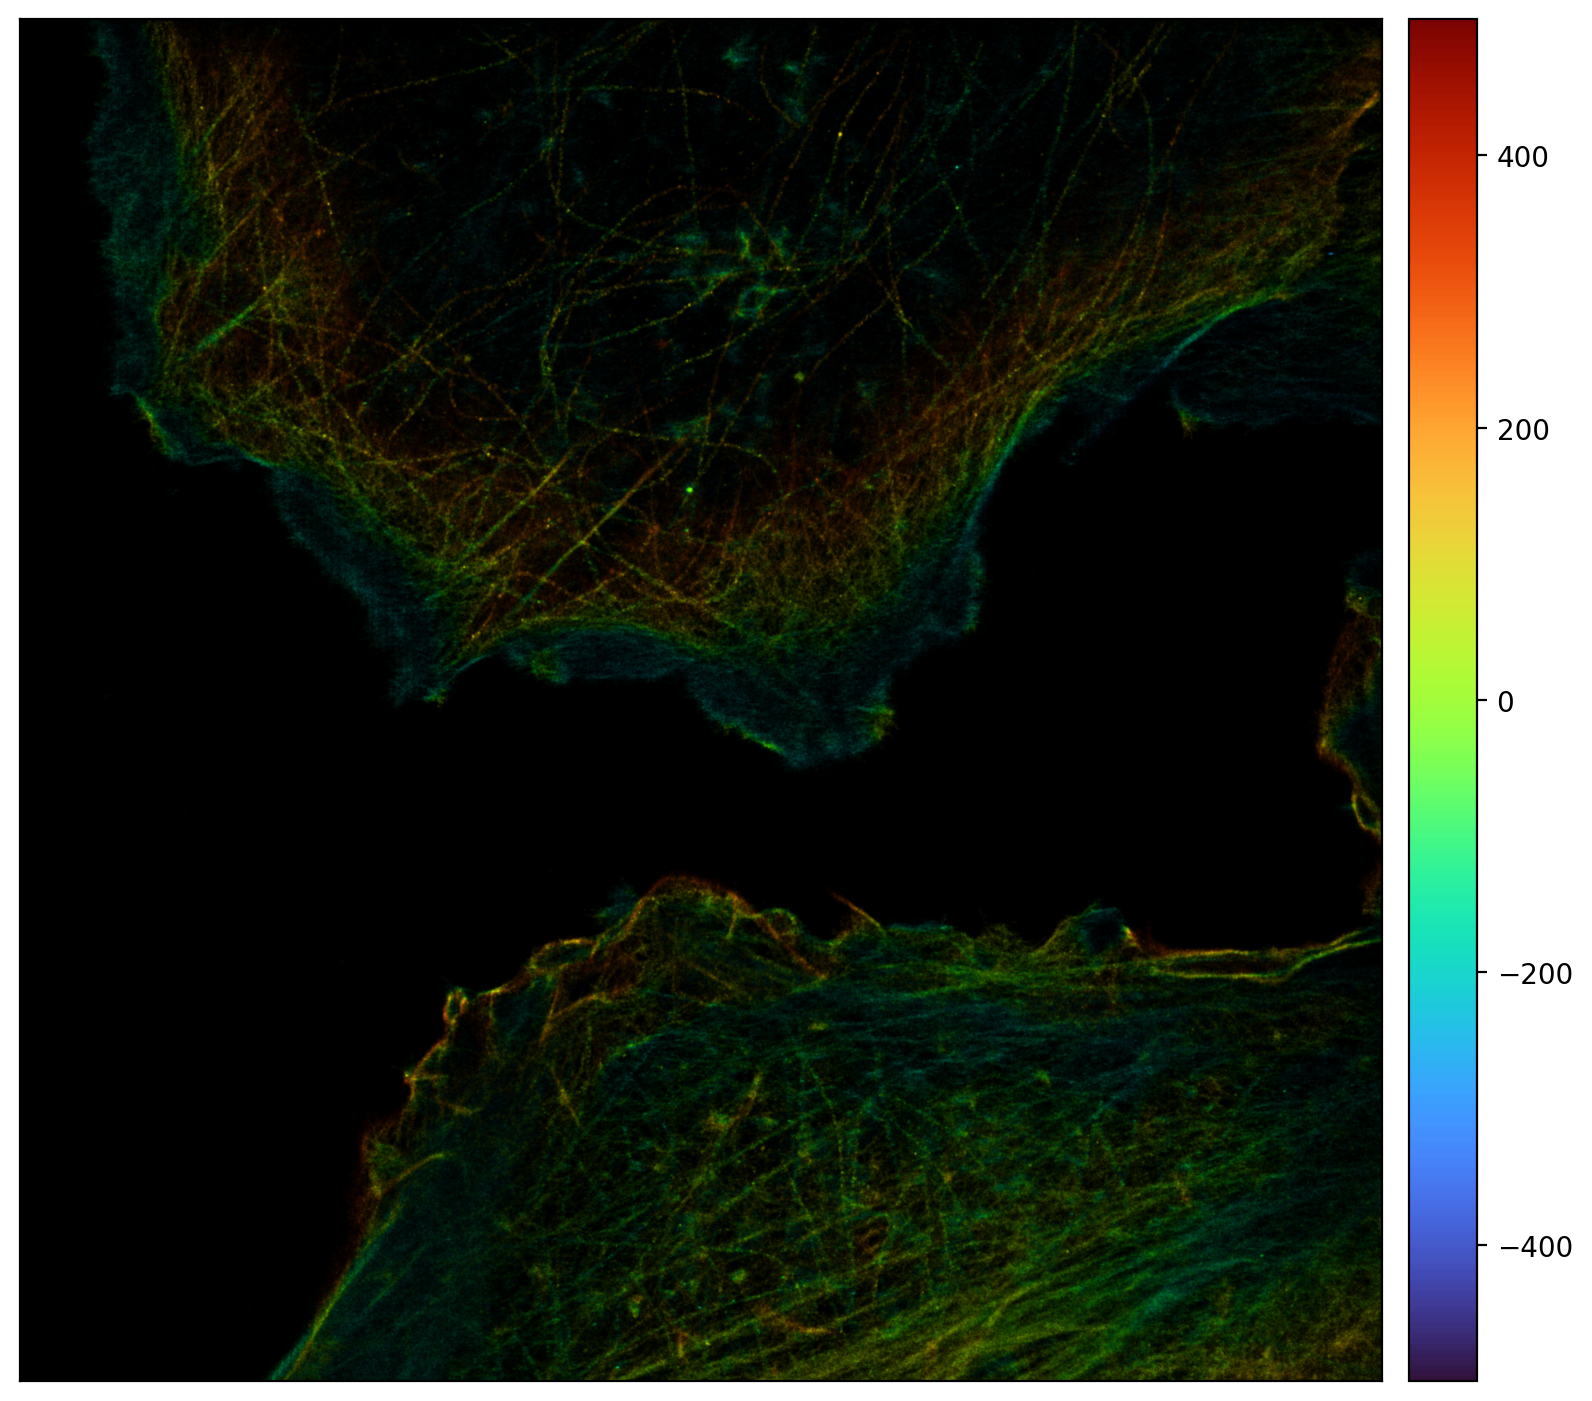

In [29]:
# rendering
import matplotlib as mpl
px_size = em_debiased.px_size

xextent = (0, 200 * px_size[0])
yextent = (0, 200 * px_size[1])
zextent = (-500., 500.)

renderer = decode.renderer.renderer.Renderer2D(
    xextent=xextent,
    yextent=xextent,
    colextent=zextent,
    px_size=10.,
    sigma_blur=10.,
    rel_clip=0.05,
    # contrast=4.,
    cmap="turbo",
)

img = renderer.forward(em_debiased, em_debiased.xyz[:, 2])


fig, ax = plt.subplots(figsize=(8, 8))

im = ax.imshow(img.permute(1, 0, 2))

plt.xticks([])
plt.yticks([])
# plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
# Create an inset_axes for the colorbar next to each subplot
cmap = mpl.cm.turbo
# Adjust the [left, bottom, width, height] values as needed for your layout
cbar_ax = ax.inset_axes([1.02, 0., 0.05, 1.])

# Create a ScalarMappable with the turbo colormap and normalization
norm = mpl.colors.Normalize(vmin=zextent[0], vmax=zextent[1])
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Add the colorbar to the inset_axes
fig.colorbar(sm, cax=cbar_ax, fraction=0.046, pad=0.04)


plt.tight_layout()